# Notebook de Integrante 3

## Proyecto 2026 – Funciones y Análisis Ambiental con Pandas

Universidad de Cundinamarca


## 1. Objetivo

Escribir aquí el objetivo del análisis.




Analizar el comportamiento de la humedad del compost durante el proceso de descomposición y estudiar su influencia en la velocidad de degradación de los residuos orgánicos mediante un modelo matemático basado en humedad y temperatura.

## 2. Importación de librerías


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Carga de datos

Aquí se carga el archivo ubicado en la carpeta `data`.


In [6]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\usuario\proyecto-2026\data\datos_compost.xlsx"
)

df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])

df.head()

,Fecha_Hora,Temp_Invernadero,Humedad_Invernadero,Temp_Exterior,Humedad_Exterior,Temp_Compost,Humedad_Compost
0,2026-05-16 00:08:55,14.1,89.0,14.1,71.0,16.87,89.0
1,2026-05-16 00:07:47,14.3,88.0,14.1,71.0,16.87,88.0
2,2026-05-16 00:06:37,14.4,88.0,14.1,72.0,16.87,88.0
3,2026-05-16 00:05:29,14.7,88.0,14.1,71.0,16.87,88.0
4,2026-05-16 00:04:21,14.2,88.0,14.1,71.0,16.87,88.0


## 4. Análisis de datos

Aquí se realiza el análisis con Pandas.


In [7]:
def estadisticas_humedad(df):
    return {
        "Minima": df["Humedad_Compost"].min(),
        "Maxima": df["Humedad_Compost"].max(),
        "Promedio": df["Humedad_Compost"].mean(),
        "Desviacion": df["Humedad_Compost"].std()
    }

estadisticas_humedad(df)

{'Minima': 13.0,
 'Maxima': 96.0,
 'Promedio': np.float64(71.13222806308127),
 'Desviacion': 30.302812101977946}

CALSIFICACIÓN

In [8]:
def clasificar_humedad(h):

    if h < 40:
        return "Baja"

    elif h <= 60:
        return "Adecuada"

    else:
        return "Alta"

df["Estado_Humedad"] = df["Humedad_Compost"].apply(clasificar_humedad)

df[["Humedad_Compost","Estado_Humedad"]].head()

,Humedad_Compost,Estado_Humedad
0,89.0,Alta
1,88.0,Alta
2,88.0,Alta
3,88.0,Alta
4,88.0,Alta


CORRELACIÓN

In [9]:
corr = df["Humedad_Compost"].corr(df["Temp_Compost"])

print("Correlación:", corr)

Correlación: 0.28590041163014024


Modelo matemático (Markdown)
# Modelo matemático

Se utiliza la ecuación:

dR/dt = -k H(t) T(t) R(t)

donde:

- R(t) representa la cantidad de residuos orgánicos.
- H(t) representa la humedad.
- T(t) representa la temperatura.
- k es la constante de descomposición.

In [11]:
print("""
Modelo matemático

dR/dt = -k H(t) T(t) R(t)

R(t): cantidad de residuos
H(t): humedad
T(t): temperatura
k: constante de descomposición
""")


Modelo matemático

dR/dt = -k H(t) T(t) R(t)

R(t): cantidad de residuos
H(t): humedad
T(t): temperatura
k: constante de descomposición



In [ ]:
# Escribir aquí el análisis


## 5. Gráficas

Aquí se pueden generar gráficas de los resultados.


Gráfica de humedad

In [4]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\usuario\proyecto-2026\data\datos_compost.xlsx"
)

df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])

df.head()

,Fecha_Hora,Temp_Invernadero,Humedad_Invernadero,Temp_Exterior,Humedad_Exterior,Temp_Compost,Humedad_Compost
0,2026-05-16 00:08:55,14.1,89.0,14.1,71.0,16.87,89.0
1,2026-05-16 00:07:47,14.3,88.0,14.1,71.0,16.87,88.0
2,2026-05-16 00:06:37,14.4,88.0,14.1,72.0,16.87,88.0
3,2026-05-16 00:05:29,14.7,88.0,14.1,71.0,16.87,88.0
4,2026-05-16 00:04:21,14.2,88.0,14.1,71.0,16.87,88.0


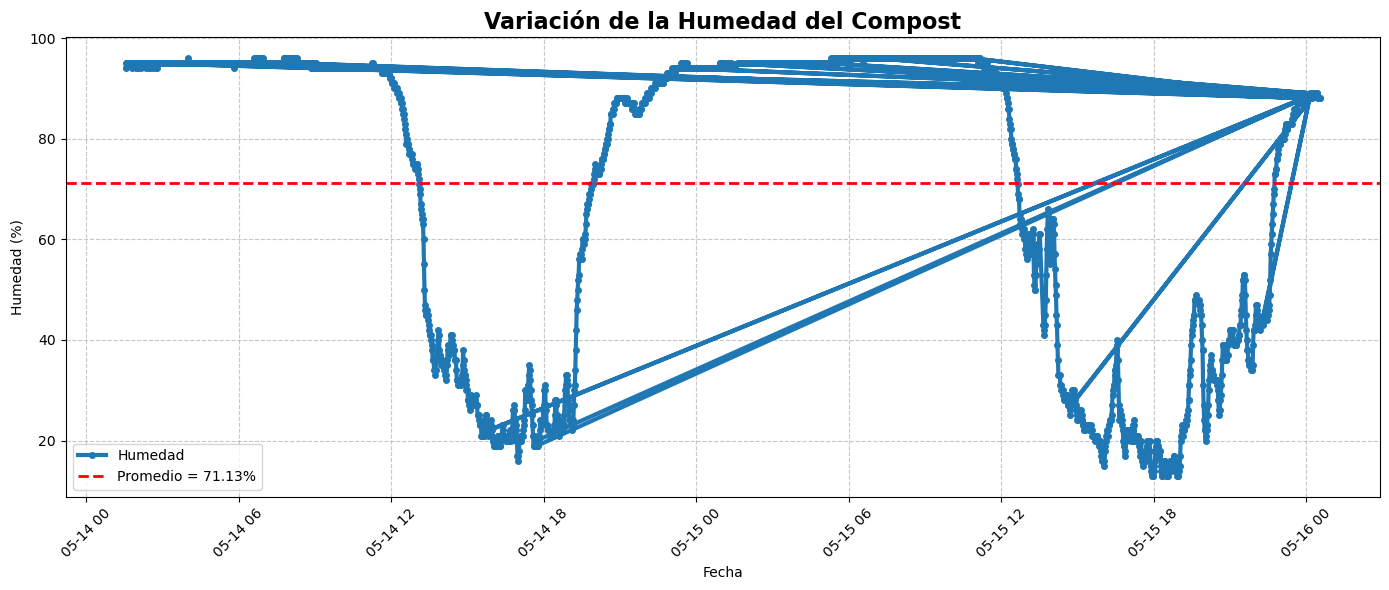

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Fecha_Hora"],
    df["Humedad_Compost"],
    linewidth=3,
    marker="o",
    markersize=4,
    label="Humedad"
)

promedio = df["Humedad_Compost"].mean()

plt.axhline(
    promedio,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Promedio = {promedio:.2f}%"
)

plt.title(
    "Variación de la Humedad del Compost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Humedad (%)")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

Gráfica 2: Relación Humedad vs Temperatura

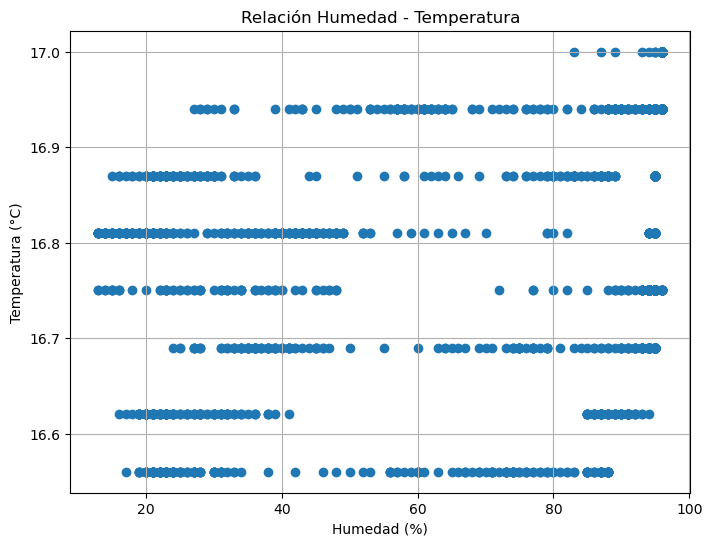

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Humedad_Compost"],
    df["Temp_Compost"]
)

plt.xlabel("Humedad (%)")

plt.ylabel("Temperatura (°C)")

plt.title("Relación Humedad - Temperatura")

plt.grid(True)

plt.show()

Gráfica 3: Modelo RK2 de reducción de residuos

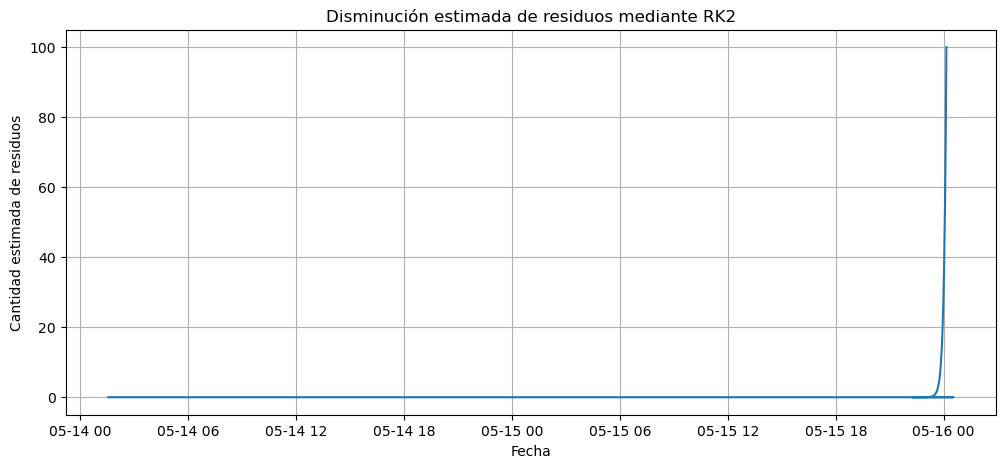

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Fecha_Hora"],
    df["Residuos_Modelados"]
)

plt.title(
    "Disminución estimada de residuos mediante RK2"
)

plt.xlabel("Fecha")

plt.ylabel("Cantidad estimada de residuos")

plt.grid(True)

plt.show()

el modelo matemático basado en Runge-Kutta de segundo orden muestra una disminución progresiva de la cantidad de residuos orgánicos a medida que avanza el proceso de compostaje.

Con esas tres gráficas ya cubres:

Humedad en el tiempo.
Relación humedad-temperatura.
Modelo matemático RK2.

Es un conjunto bastante completo para la sección de Humedad del Compost y se ve mucho más elaborado que limitarse a imprimir promedio, mínimo y máximo.

# Conclusiones

- La humedad presentó variaciones durante el proceso de compostaje.
- Se identificaron periodos de humedad baja, adecuada y alta.
- La humedad y la temperatura mostraron una relación importante para la actividad biológica del compost.
- El modelo diferencial permitió estimar la reducción de residuos orgánicos a lo largo del tiempo.
- La implementación de Runge-Kutta de segundo orden permitió aproximar numéricamente el comportamiento del proceso de descomposición.
- Los resultados sugieren que la humedad influye significativamente en la velocidad de degradación del compost.